<a href="https://colab.research.google.com/github/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/3_2_dimensionality_reduction/0_2_PCA_scratch_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA From Scratch: Geometry, Implementation, and Interpretation

This notebook explores Principal Component Analysis (PCA) from first principles through implementation, visualization, and interpretation.

We build PCA from scratch using NumPy, then compare it with `scikit-learn` to validate correctness. Along the way, we visualize how PCA rotates high-dimensional data into directions of maximum variance and reduces dimensionality while preserving structure.

Using synthetic and real datasets (including Wine and Digits), we explore explained variance, feature loadings, reconstruction error, and the effect of standardization.

The goal is to develop a clear geometric and practical understanding of PCA beyond its use as a black-box dimensionality reduction method.

# PCA From Scratch

In [1]:
# Part 0 - Imports
import numpy as np
import matplotlib.pyplot as plt

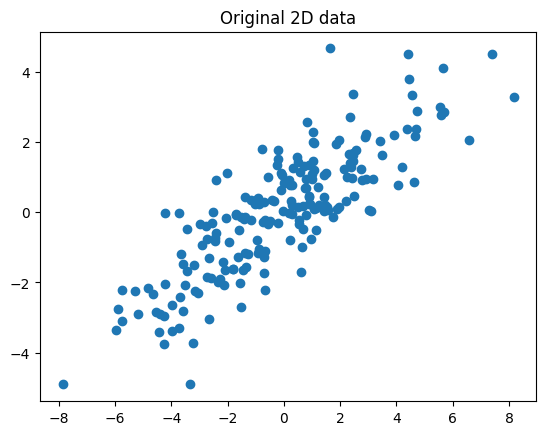

In [2]:
# Part 1 - Create a 2D dataset where PCA is obvious
np.random.seed(42)

# create x as 200 samples from N(0, 3)
x = np.random.normal(0, 3, 200)

# create y so that it is correlated with x (hint: 0.5 * x + noise)
y = 0.5 * x + np.random.normal(0, 1, 200)

# stack x and y into matrix X of shape (200, 2)
X = np.column_stack((x, y))

plt.scatter(X[:, 0], X[:, 1])
plt.title("Original 2D data")
plt.show()

In [3]:
# Part 2 -  Center the data
# compute mean of X (per column)
X_mean = np.mean(X, axis=0)

# center the data
X_centered = X - X_mean

print(X_mean)

[-0.1223129   0.02471174]


In [4]:
# Part 3 -  compute covariance matrix of X_centered
cov_matrix = np.cov(X_centered, rowvar=False)

print(cov_matrix)

[[7.80091461 4.16274942]
 [4.16274942 3.18669729]]


In [5]:
# Part 4 -  Eigen decomposition
# eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [10.25313711  0.73447479]
Eigenvectors:
 [[ 0.86161326 -0.50756536]
 [ 0.50756536  0.86161326]]


In [6]:
# Part 5 - Sort components by importance
# sort indices of eigenvalues in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]

# reorder eigenvalues and eigenvectors
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

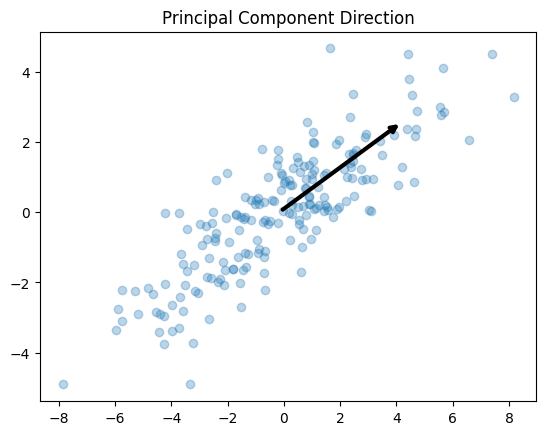

In [7]:
# Part 6 - Visualize the principal direction
plt.scatter(X[:,0], X[:,1], alpha=0.3)

# take the first eigenvector
v = eigenvectors[:,0]

# draw the vector starting from mean
plt.annotate(
    '',
    xy=(X_mean[0] + 5*v[0], X_mean[1] + 5*v[1]),
    xytext=(X_mean[0], X_mean[1]),
    arrowprops=dict(arrowstyle='->', linewidth=3)
)

plt.title("Principal Component Direction")
plt.show()

In [8]:
# Part 7 - Project data to 1D (2D → 1D)
# select first eigenvector as component matrix (shape (2,1))
component = eigenvectors[:, :1]

# project centered data onto this component
X_reduced = np.dot(X_centered, component)

print(X_reduced.shape)

(200, 1)


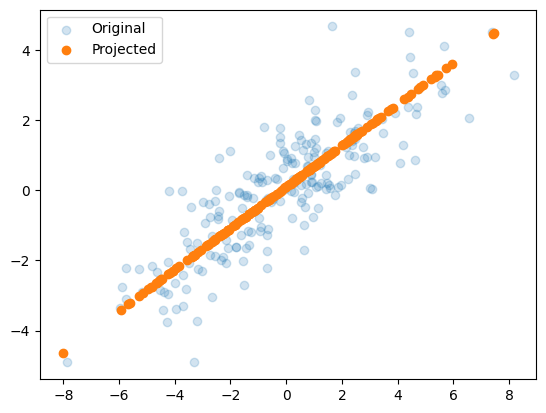

In [9]:
# Part 8 - Reconstruct back to 2D for visualization
#  reconstruct points back to 2D
X_projected = X_reduced @ component.T + X_mean

plt.scatter(X[:,0], X[:,1], alpha=0.2, label="Original")
plt.scatter(X_projected[:,0], X_projected[:,1], label="Projected")
plt.legend()
plt.show()

## PCA function

In [51]:
# Part 9 - Wrap everything into a PCA function
def pca_from_scratch(X, n_components):
    # Center
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Covariance
    cov = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)

    # Eigen
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Select components
    components = eigenvectors[:, :n_components]

    # Project
    X_reduced = X_centered @ components

    return X_reduced, components, eigenvalues

## Iris - smoke test

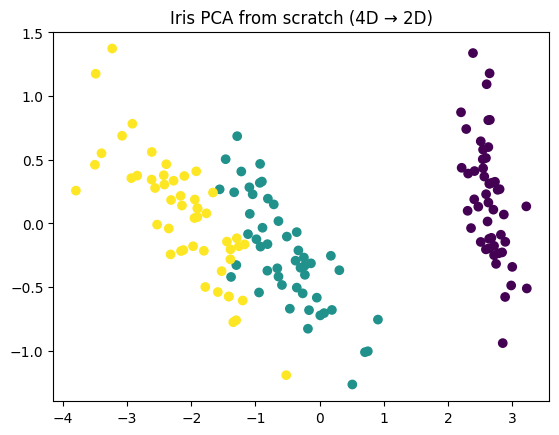

In [11]:
# Part 10 - Apply PCA to a real dataset (4D → 2D)
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris_reduced, components_iris, eigenvalues_iris = pca_from_scratch(X_iris, 2)

plt.scatter(X_iris_reduced[:,0], X_iris_reduced[:,1], c=y_iris)
plt.title("Iris PCA from scratch (4D → 2D)")
plt.show()

# PCA Experiments - Wine datase

In [52]:
# Part 1 - Load data
from sklearn.datasets import load_wine
import numpy as np
import matplotlib.pyplot as plt

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(X_wine.shape)  # (178, 13)

(178, 13)


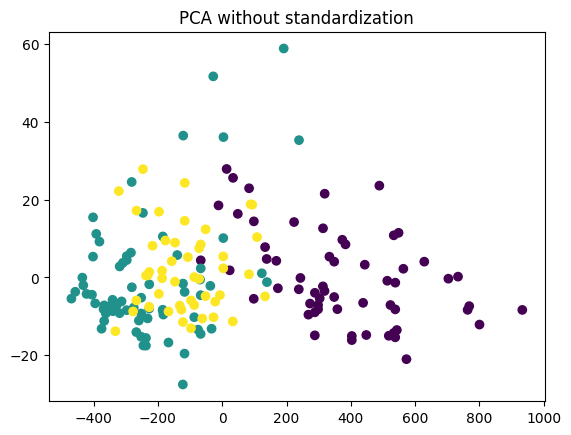

In [53]:
# Part 2 - PCA without standardization
X_wine_reduced, components_wine, eigenvalues_wine = pca_from_scratch(X_wine, 2)

plt.scatter(X_wine_reduced[:,0], X_wine_reduced[:,1], c=y_wine)
plt.title("PCA without standardization")
plt.show()

In [54]:
# Part 3 - Standardize features
# Standardize manually
mean_wine = np.mean(X_wine, axis=0)
std_wine = np.std(X_wine, axis=0)

X_wine_std = (X_wine - mean_wine) / std_wine

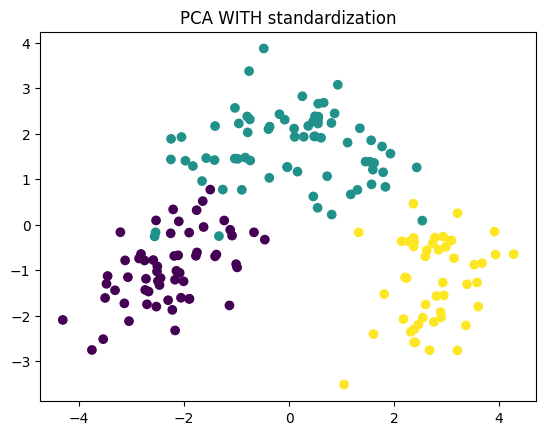

In [55]:
X_wine_reduced_std, components_wine, eigenvalues_wine = pca_from_scratch(X_wine_std, 2)

plt.scatter(X_wine_reduced_std[:,0], X_wine_reduced_std[:,1], c=y)
plt.title("PCA WITH standardization")
plt.show()

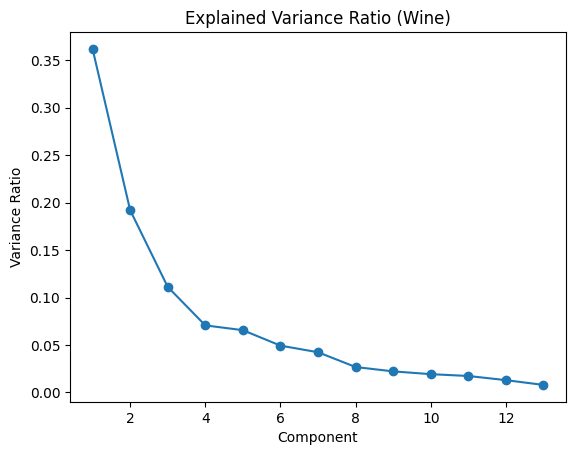

In [78]:
# Part 4 - Explained variance plot
def plot_explained_variance(eigenvalues, title="Explained Variance Ratio"):
    explained = eigenvalues / np.sum(eigenvalues)
    n = len(explained)

    plt.plot(range(1, n + 1), explained, marker='o')
    plt.title(title)
    plt.xlabel("Component")
    plt.ylabel("Variance Ratio")
    plt.show()

plot_explained_variance(eigenvalues_wine, title="Explained Variance Ratio (Wine)")

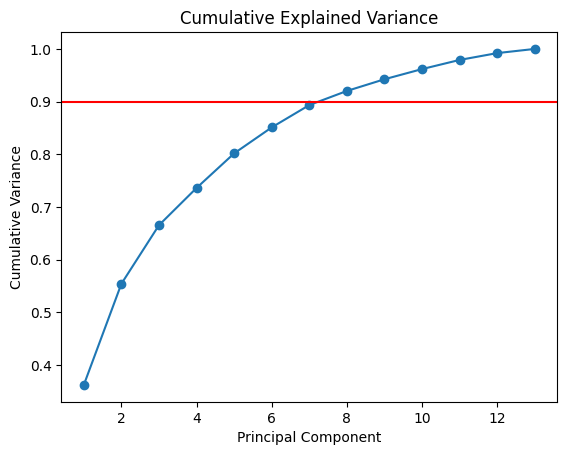

Components needed for 90% variance: 8


np.int64(8)

In [80]:
# Part 5 - How many components for 90% variance
def plot_cumulative_variance(eigenvalues, threshold=0.9,
                             title="Cumulative Explained Variance"):
    explained = eigenvalues / np.sum(eigenvalues)
    cumulative = np.cumsum(explained)
    n = len(cumulative)

    plt.plot(range(1, n + 1), cumulative, marker='o')
    plt.axhline(threshold, c='r')
    plt.title(title)
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance")
    plt.show()

    k = np.argmax(cumulative >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {k}")
    return k

plot_cumulative_variance(eigenvalues_wine, threshold=0.9)

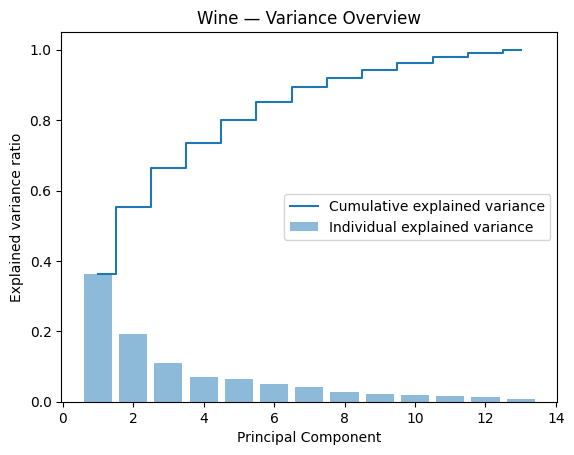

In [82]:
# Combine individual and cumulative variance on one plot
def plot_variance_bars(eigenvalues,
                       title="Explained vs Cumulative Variance"):
    explained = eigenvalues / np.sum(eigenvalues)
    cumulative = np.cumsum(explained)
    n = len(explained)

    plt.bar(range(1, n + 1), explained, alpha=0.5,
            align='center', label='Individual explained variance')

    plt.step(range(1, n + 1), cumulative, where='mid',
             label='Cumulative explained variance')

    plt.xlabel('Principal Component')
    plt.ylabel('Explained variance ratio')
    plt.title(title)
    plt.legend(loc='best')
    plt.show()

plot_variance_bars(eigenvalues_wine, "Wine — Variance Overview")

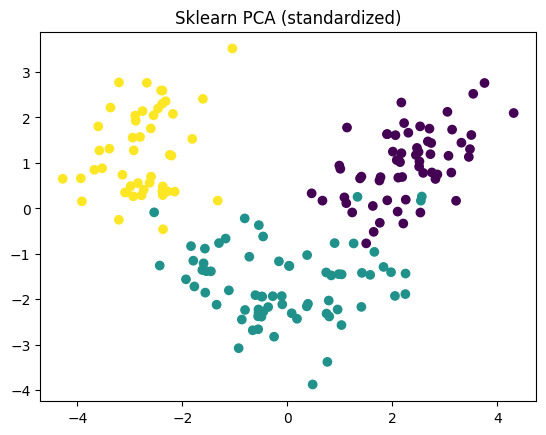

In [67]:
# Part 6 - Compare with sklearn PCA
from sklearn.decomposition import PCA

pca_wine = PCA(n_components=2)
X_wine_sklearn = pca_wine.fit_transform(X_wine_std)

plt.scatter(X_wine_sklearn[:,0], X_wine_sklearn[:,1], c=y)
plt.title("Sklearn PCA (standardized)")
plt.show()

In [72]:
# sklearn PCA may appear mirrored or axes may have opposite signs.
# This is expected because eigenvectors are defined up to sign.
np.allclose(X_wine_reduced_std, -X_wine_sklearn)

True

# 3D visualizations

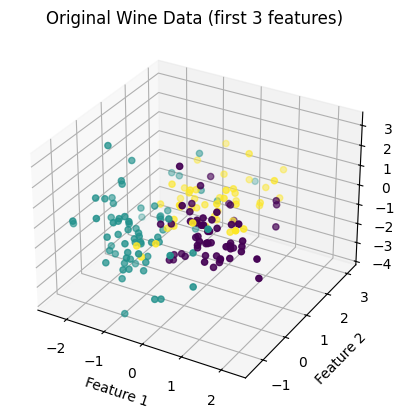

In [89]:
import matplotlib.pyplot as plt

def plot_3d_original(X, y, title="Original Wine Data (first 3 features)"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[:,0], X[:,1], X[:,2], c=y)

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.set_title(title)

    plt.show()

plot_3d_original(X_wine_std, y)

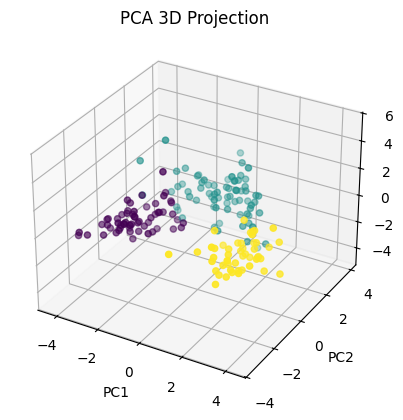

In [86]:
def plot_3d_pca(X_reduced, y, title="PCA 3D Projection"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X_reduced[:,0],
               X_reduced[:,1],
               X_reduced[:,2],
               c=y)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)

    plt.show()

X_wine_reduced_3d, components_wine, _ = pca_from_scratch(X_wine_std, 3)

plot_3d_pca(X_wine_reduced_3d, y)

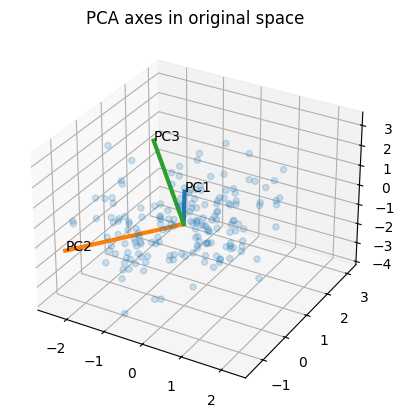

In [98]:
def plot_pca_axes(X, components, mean, title="PCA axes in original space"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.2)

    labels = ["PC1", "PC2", "PC3"]

    for i in range(3):
        vec = components[:, i]
        end = mean + 5 * vec
        ax.plot([mean[0], mean[0] + 5*vec[0]],
                [mean[1], mean[1] + 5*vec[1]],
                [mean[2], mean[2] + 5*vec[2]],
                linewidth=3)
        ax.text(end[0], end[1], end[2],
                labels[i],
                fontsize=10)

    ax.set_title(title)
    plt.show()

plot_pca_axes(X_wine_std, components_wine[:, :3], np.mean(X_wine_std, axis=0))

A principal component may appear shorter in a 3D visualization because we are only showing a projection of a 13D direction. However, its explained variance is determined by its eigenvalue in the full space, not its visual length.

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def plot_3d_pca_depth(
    X,
    y,
    n_components=3,
    limit=22,
    cmap='tab10',
    point_base_size=3,
    point_scale=60,
    figsize=(16, 12),
    name='',
    random_state=0
):
    """
    3D PCA scatter with depth-based point scaling.
    """

    # --- PCA ---
    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X)

    # --- Figure ---
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)

    sc = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        X_pca[:, 2],
        c=y,
        cmap=cmap,
        alpha=0.6
    )

    ax.set_title(f'3D PCA with Depth-Scaled Points {name}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')

    # --- update function ---
    def update_sizes(event=None):
        elev = np.deg2rad(ax.elev)
        azim = np.deg2rad(ax.azim)

        cam_dir = np.array([
            np.cos(elev) * np.cos(azim),
            np.cos(elev) * np.sin(azim),
            np.sin(elev)
        ])

        depth = X_pca @ cam_dir

        depth_norm = (depth - depth.min()) / (depth.max() - depth.min())

        sizes = point_base_size + (1 - depth_norm) * point_scale

        sc.set_sizes(sizes)
        fig.canvas.draw_idle()

    # --- legend ---
    legend = ax.legend(*sc.legend_elements(), title="Class")
    ax.add_artist(legend)

    # --- interactivity ---
    fig.canvas.mpl_connect('motion_notify_event', update_sizes)

    # initial render
    update_sizes()

    plt.show()

    return pca, X_pca

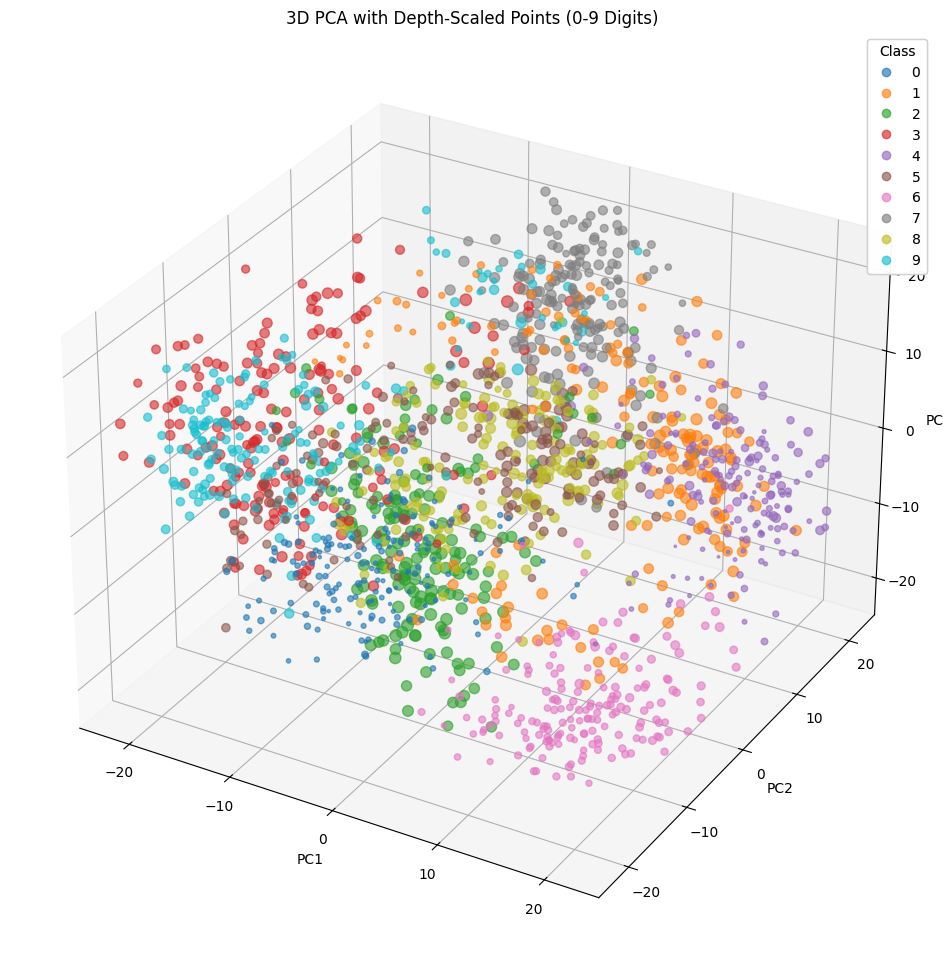

In [124]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

pca_model, X_pca = plot_3d_pca_depth(
    X_digits,
    y_digits,
    n_components=3,
    limit=25,
    point_scale=70,
    name='(0-9 Digits)'
)

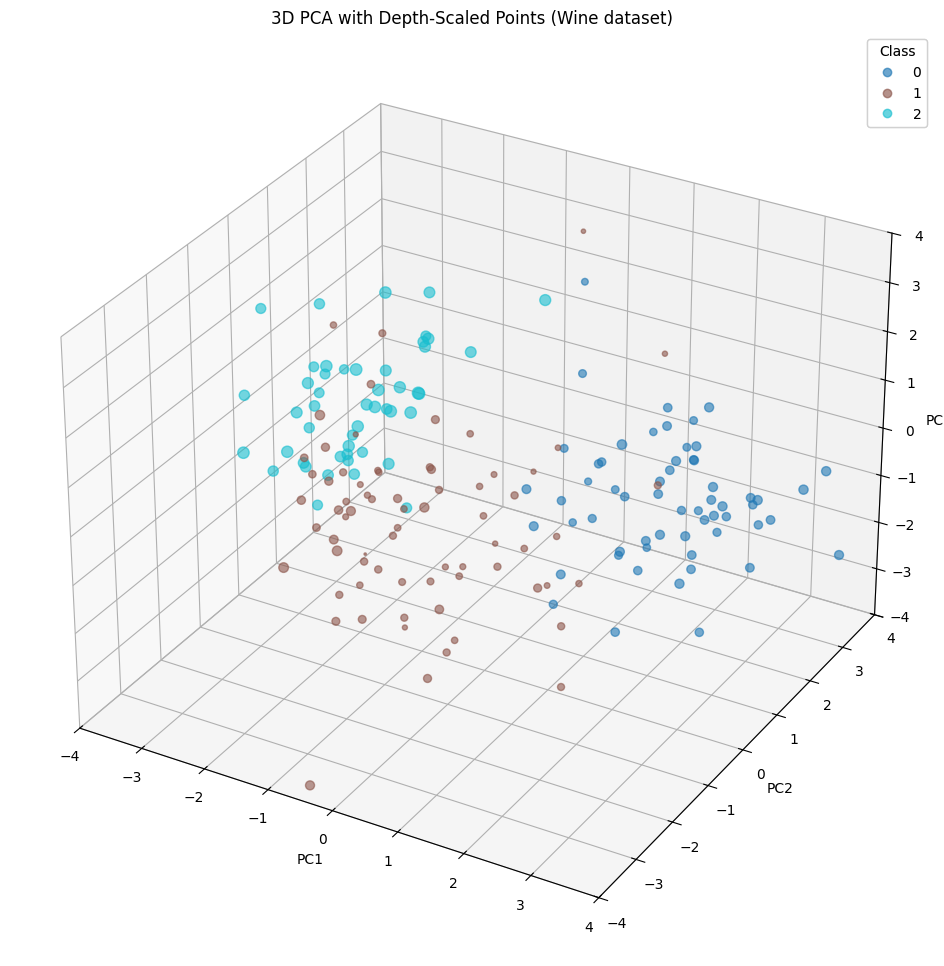

In [125]:
pca_model, X_pca = plot_3d_pca_depth(
    X_wine_std,
    y_wine,
    n_components=3,
    limit=4,
    point_scale=70,
    name='(Wine dataset)'
)

In [126]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA


def plot_3d_pca_depth_plotly(
    X,
    y,
    n_components=3,
    point_size=5,
    opacity=0.7,
    title="3D PCA with Depth Effect (Plotly)"
):
    """
    3D PCA visualization with simulated depth effect in Plotly.
    """

    # --- PCA ---
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # --- camera-based depth approximation ---
    # (Plotly handles rotation internally; we simulate static depth scaling)
    z = X_pca[:, 2]

    z_norm = (z - z.min()) / (z.max() - z.min())
    sizes = 3 + (1 - z_norm) * 10  # closer = bigger

    # --- figure ---
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        z=X_pca[:, 2],
        mode='markers',
        marker=dict(
            size=sizes,
            color=y,
            colorscale='Turbo',
            opacity=opacity,
            showscale=True
        ),
        name="Digits"
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

    return pca, X_pca

In [133]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

pca_model, X_pca = plot_3d_pca_depth_plotly(
    X_digits,
    y_digits,
    point_size=6,
    title="3D PCA with Depth Effect (Plotly 0-9 digits)"
)

In [128]:
pca_model, X_pca = plot_3d_pca_depth_plotly(
    X_wine_std,
    y_wine,
    point_size=6,
    title="3D PCA with Depth Effect (Wine dataset)"
)

# Reconstruction error vs number of components

Idea:

Show how much information is lost when reducing dimensions

In [134]:
from sklearn.decomposition import PCA
import numpy as np

def reconstruction_error_curve(X, max_components=20):
    errors = []

    for k in range(1, max_components + 1):
        pca = PCA(n_components=k)
        X_reduced = pca.fit_transform(X)
        X_recon = pca.inverse_transform(X_reduced)

        error = np.mean((X - X_recon) ** 2)
        errors.append(error)

    return errors

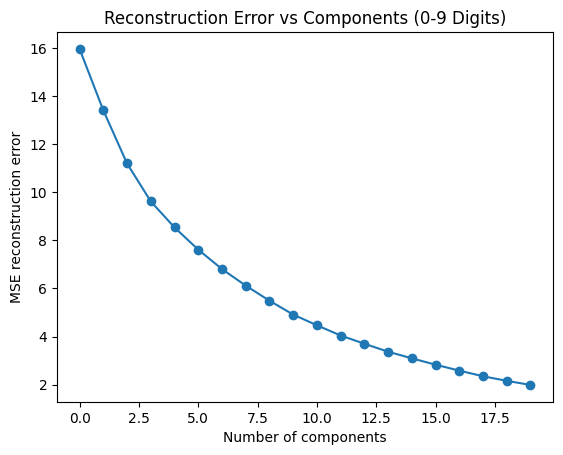

In [135]:
errors = reconstruction_error_curve(X_digits, 20)

plt.plot(errors, marker='o')
plt.title("Reconstruction Error vs Components (0-9 Digits)")
plt.xlabel("Number of components")
plt.ylabel("MSE reconstruction error")
plt.show()

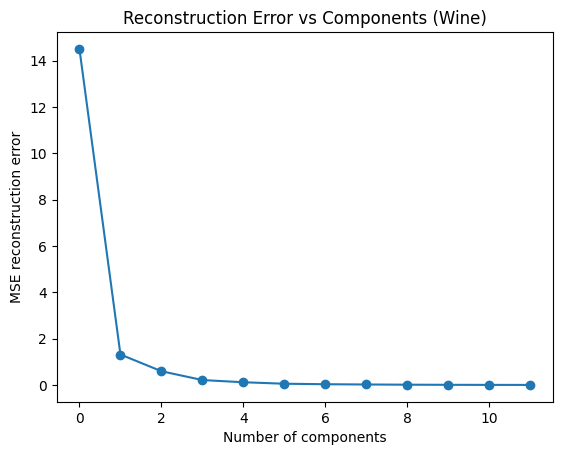

In [136]:
errors = reconstruction_error_curve(X_wine, 12)

plt.plot(errors, marker='o')
plt.title("Reconstruction Error vs Components (Wine)")
plt.xlabel("Number of components")
plt.ylabel("MSE reconstruction error")
plt.show()

# Feature contribution - Wine PCA

Idea:

Show which original features drive each PC.

In [138]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

wine = load_wine()
X = wine.data
feature_names = wine.feature_names

# standardize (VERY important for loadings)
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_std)

components = pca.components_  # shape: (n_components, n_features)

In [141]:
components.shape

(3, 13)

In [142]:
def plot_pca_loadings(components, feature_names, pc_index=0):
    loadings = components[pc_index]

    plt.figure(figsize=(10, 5))
    plt.bar(feature_names, loadings)
    plt.xticks(rotation=90)
    plt.title(f"Feature Loadings for PC{pc_index + 1}")
    plt.ylabel("Contribution")
    plt.show()

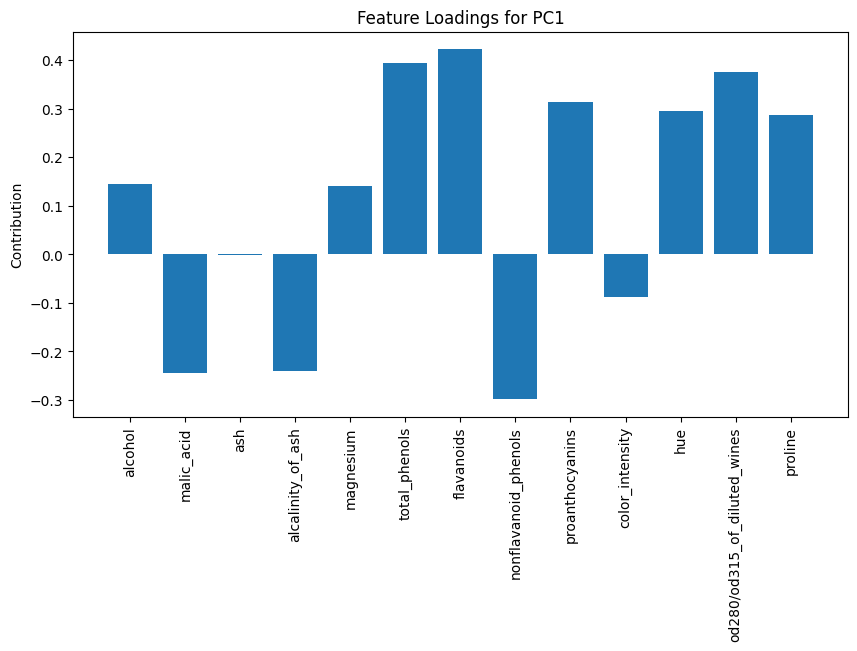

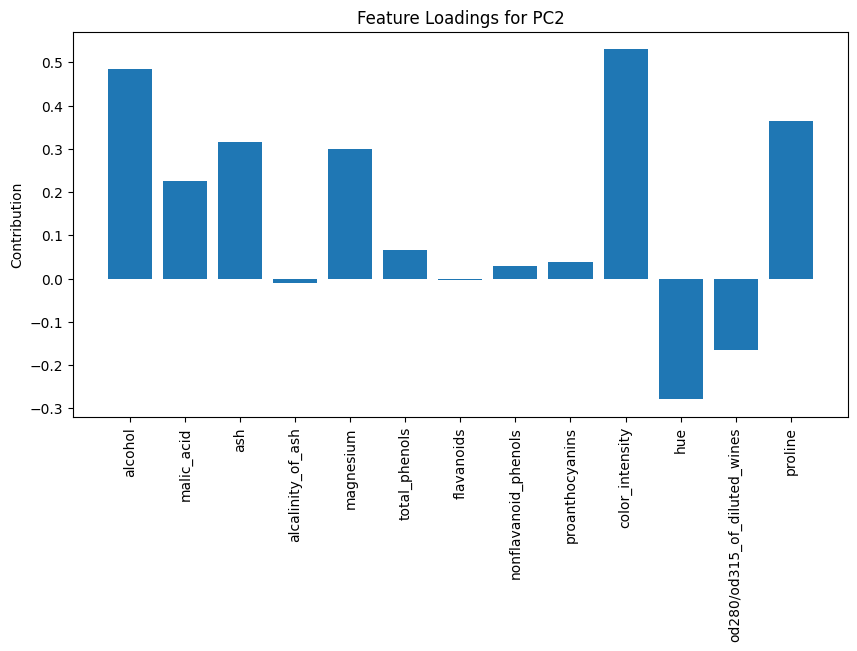

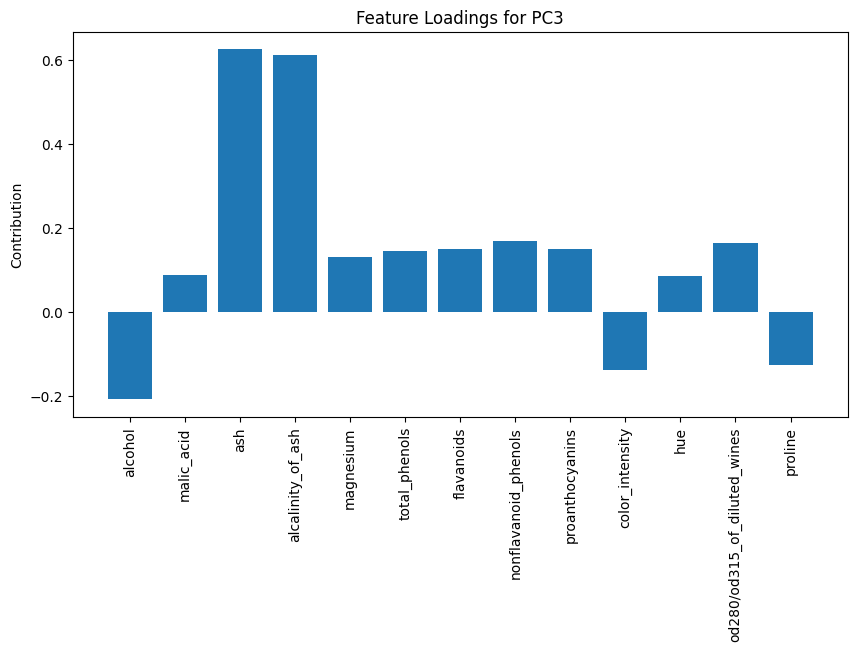

In [143]:
plot_pca_loadings(components, feature_names, pc_index=0)
plot_pca_loadings(components, feature_names, pc_index=1)
plot_pca_loadings(components, feature_names, pc_index=2)

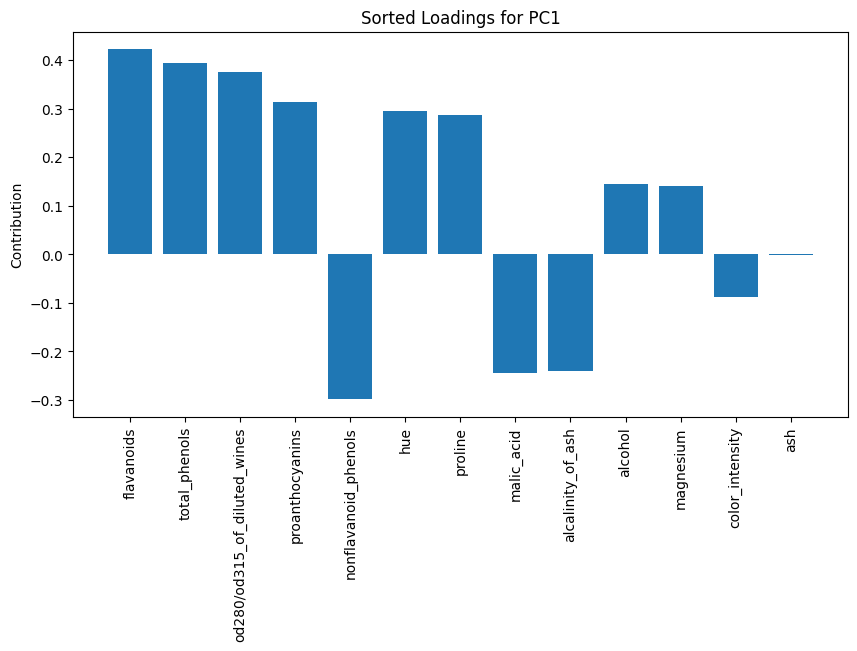

In [144]:
def plot_sorted_loadings(components, feature_names, pc_index=0):
    loadings = components[pc_index]

    idx = np.argsort(np.abs(loadings))[::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(np.array(feature_names)[idx], loadings[idx])
    plt.xticks(rotation=90)
    plt.title(f"Sorted Loadings for PC{pc_index + 1}")
    plt.ylabel("Contribution")
    plt.show()

plot_sorted_loadings(components, feature_names, 0)